# Evaluación comparativa de modelos de calidad de agua

Este notebook documenta la evaluación comparativa de los modelos entrenados para la estimación de parámetros de calidad de agua en humedales.

Los modelos evaluados son:

- Support Vector Regression (SVR),
- Gradient Boosting Regressor (GBR),
- Random Forest Regressor (RFR).

La evaluación se realiza utilizando el mismo split de entrenamiento y prueba generado durante la preparación del dataset, lo cual permite comparar los modelos bajo condiciones equivalentes.

## Objetivo

Evaluar y comparar el desempeño de los modelos entrenados mediante:

1. carga del split de entrenamiento y prueba,
2. carga de los modelos entrenados,
3. cálculo de métricas de desempeño,
4. generación de gráficas observado vs estimado,
5. comparación de RMSE entre modelos,
6. comparación general de métricas,
7. generación de la curva de deviance para Gradient Boosting Regressor,
8. exportación de tablas y figuras de evaluación.

In [1]:
from pathlib import Path
import sys
import joblib

BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales


## Importación de funciones auxiliares

Se importan funciones desde los módulos ubicados en `src/calidad_agua/`.

En este notebook se utilizan:

- `cargar_split()` para recuperar el split generado en la preparación del dataset,
- `cargar_modelos()` para cargar los modelos entrenados,
- `pipeline_evaluacion_modelos()` para calcular métricas y generar las salidas gráficas de evaluación.

In [2]:
from src.calidad_agua.preparacion import cargar_split
from src.calidad_agua.inferencia import cargar_modelos
from src.calidad_agua.evaluacion import pipeline_evaluacion_modelos

## Definición de rutas

Se definen las rutas de entrada y salida necesarias para la evaluación.

Las entradas principales son:

- el archivo `.joblib` con el split de entrenamiento y prueba,
- los modelos entrenados almacenados en la carpeta del parámetro modelado.

Las salidas principales son:

- tabla de métricas comparativas,
- gráficas observado vs estimado,
- gráfica de comparación de RMSE,
- gráfica comparativa de métricas,
- curva de deviance para Gradient Boosting Regressor.

In [3]:
# ============================================================
# PARÁMETRO DE SALIDA
# ============================================================

# Debe coincidir con el nombre limpio usado en el notebook 02.
# Ejemplo: si target_modelo = "ln_DQO", entonces parametro_salida = "DQO".
parametro_salida = "DQO"

ruta_split = BASE_DIR / "data" / "interim" / "calidad_agua" / "splits" / f"split_{parametro_salida}.joblib"

print("Ruta del split:")
print(ruta_split)

Ruta del split:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\interim\calidad_agua\splits\split_DQO.joblib


## Carga del split y metadatos

Se carga el split generado en el notebook de preparación del dataset.

Este archivo contiene los conjuntos `X_train`, `X_test`, `y_train` y `y_test`, así como metadatos del flujo de modelado, incluyendo la variable objetivo, las variables predictoras y la configuración de transformación logarítmica.

In [4]:
split_data = cargar_split(ruta_split)

X_train = split_data["X_train"]
X_test = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]

target_modelo = split_data["target_modelo"]
target_salida = split_data["target_salida"]
vars_pred = split_data["vars_pred"]

crear_ln = split_data["crear_ln"]
aplicar_log = split_data["aplicar_log"]
param_cols_log = split_data["param_cols_log"]
valor_reemplazo_log = split_data["valor_reemplazo_log"]
n_registros = split_data["n_registros"]

test_size = split_data["test_size"]
random_state = split_data["random_state"]

print("Split cargado correctamente.")

print("\nVariable objetivo usada para modelado:")
print(target_modelo)

print("\nNombre limpio para salidas:")
print(target_salida)

print("\n¿Se crearon columnas logarítmicas?")
print(crear_ln)

print("\n¿El target usa transformación logarítmica?")
print(aplicar_log)

print("\nColumnas base transformadas:")
print(param_cols_log)

print("\nNúmero de registros usado:")
print(n_registros)

print("\nDimensiones:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Split cargado correctamente.

Variable objetivo usada para modelado:
ln_DQO

Nombre limpio para salidas:
DQO

¿Se crearon columnas logarítmicas?
True

¿El target usa transformación logarítmica?
True

Columnas base transformadas:
['DQO', 'Fosfatos', 'Turbidez', 'Nitratos', 'Sulfatos', 'ficocianin', 'Chl', 'CE']

Número de registros usado:
65

Dimensiones:
X_train: (55, 17)
X_test: (10, 17)
y_train: (55,)
y_test: (10,)


## Definición de rutas de modelos y salidas

A partir de `target_salida` se definen las rutas de los modelos entrenados y las carpetas de salida para métricas y figuras.

Esto permite que los productos se organicen bajo el nombre limpio del parámetro, aunque el modelo haya sido entrenado con una variable transformada como `ln_DQO`.

In [5]:
carpeta_modelos = BASE_DIR / "models" / "calidad_agua" / "entrenados" / target_salida

rutas_modelos = {
    "SVR": carpeta_modelos / "SVR.joblib",
    "GBR": carpeta_modelos / "GBR.joblib",
    "RFR": carpeta_modelos / "RFR.joblib"
}

ruta_metricas = BASE_DIR / "outputs" / "tables" / "calidad_agua" / target_salida / "metricas_modelos.csv"

carpeta_figuras = BASE_DIR / "outputs" / "figures" / "calidad_agua" / target_salida

print("Rutas de modelos:")
for nombre_modelo, ruta_modelo in rutas_modelos.items():
    print(f"{nombre_modelo}: {ruta_modelo}")

print("\nRuta de tabla de métricas:")
print(ruta_metricas)

print("\nCarpeta de figuras:")
print(carpeta_figuras)

Rutas de modelos:
SVR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\SVR.joblib
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\GBR.joblib
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\RFR.joblib

Ruta de tabla de métricas:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\metricas_modelos.csv

Carpeta de figuras:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO


## Carga de modelos entrenados

Se cargan los tres modelos entrenados previamente:

- `SVR.joblib`,
- `GBR.joblib`,
- `RFR.joblib`.

Estos modelos fueron generados en el notebook de entrenamiento y se encuentran almacenados en la carpeta correspondiente al parámetro de calidad de agua modelado.

In [6]:
modelos = cargar_modelos(rutas_modelos)

print("Modelos cargados correctamente:")

for nombre_modelo in modelos.keys():
    print(nombre_modelo)

Modelos cargados correctamente:
SVR
GBR
RFR


## Evaluación de modelos

Se ejecuta el pipeline completo de evaluación multimodelo.

Este proceso calcula las métricas de desempeño para entrenamiento y prueba, genera las gráficas de evaluación y guarda los productos en las carpetas de salida definidas.

Evaluando modelo: SVR
Evaluando modelo: GBR
Evaluando modelo: RFR
Tabla de métricas guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\metricas_modelos.csv
Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\observado_estimado_SVR.png


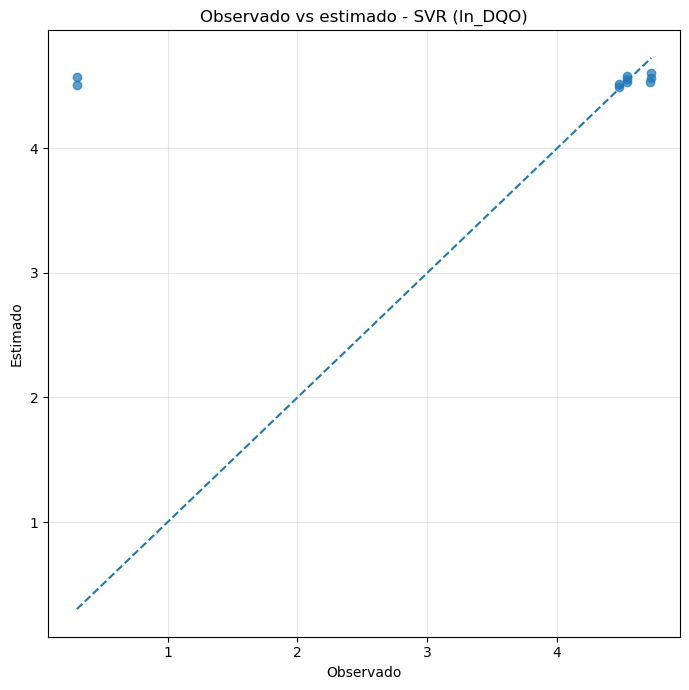

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\observado_estimado_GBR.png


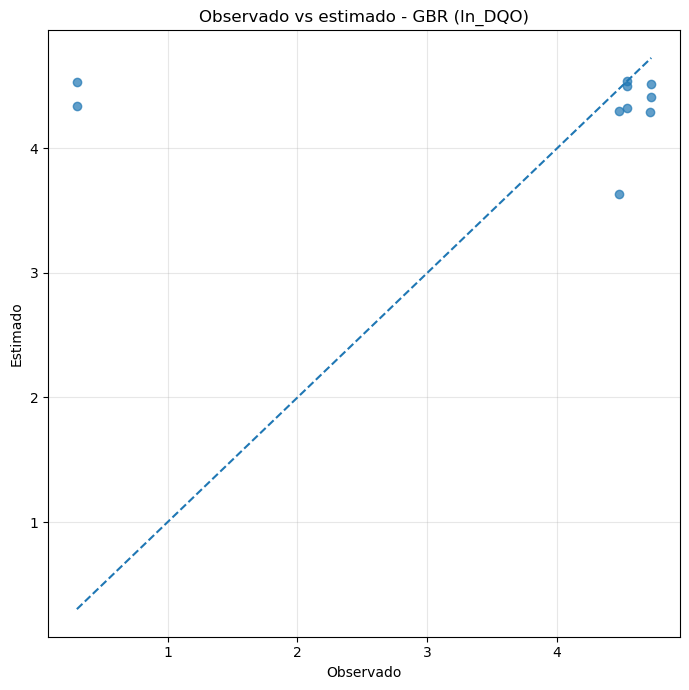

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\observado_estimado_RFR.png


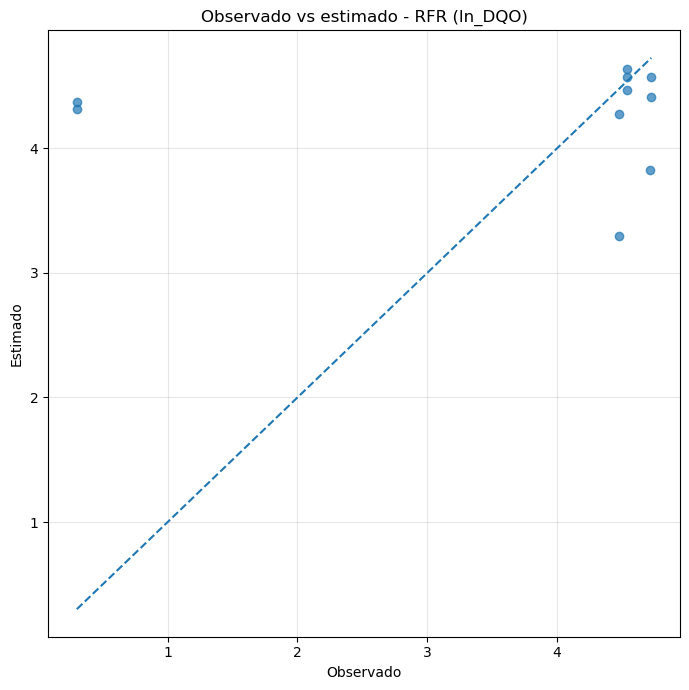

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\comparacion_rmse_modelos.png


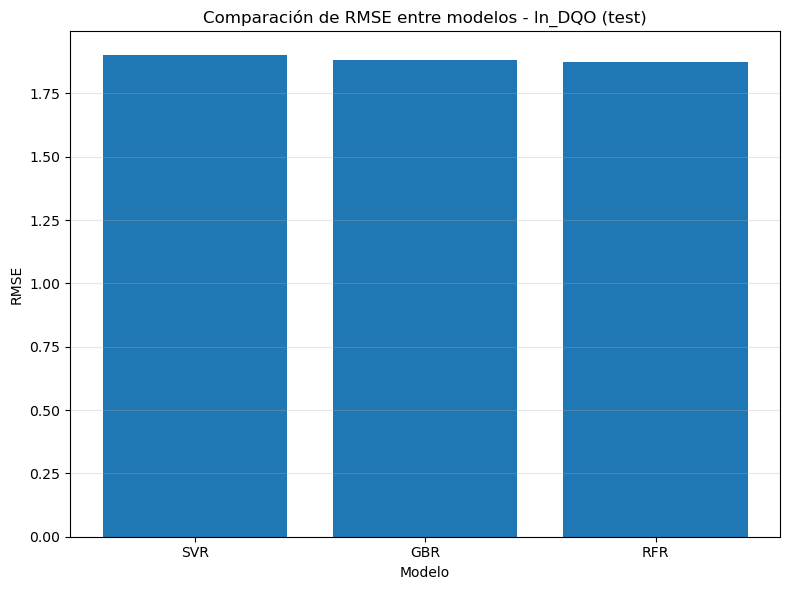

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\comparacion_metricas_modelos.png


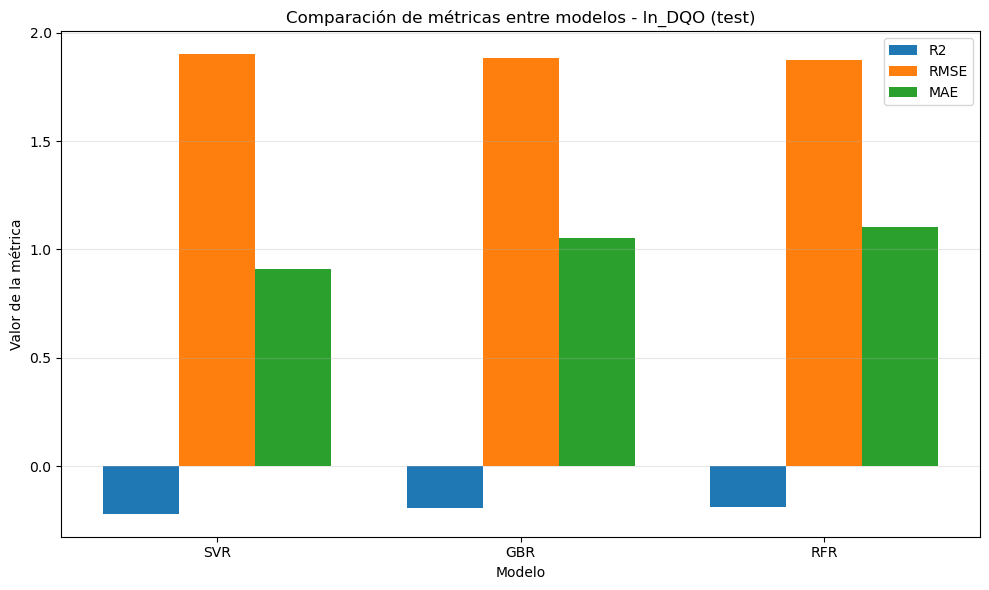

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\deviance_gbr.png


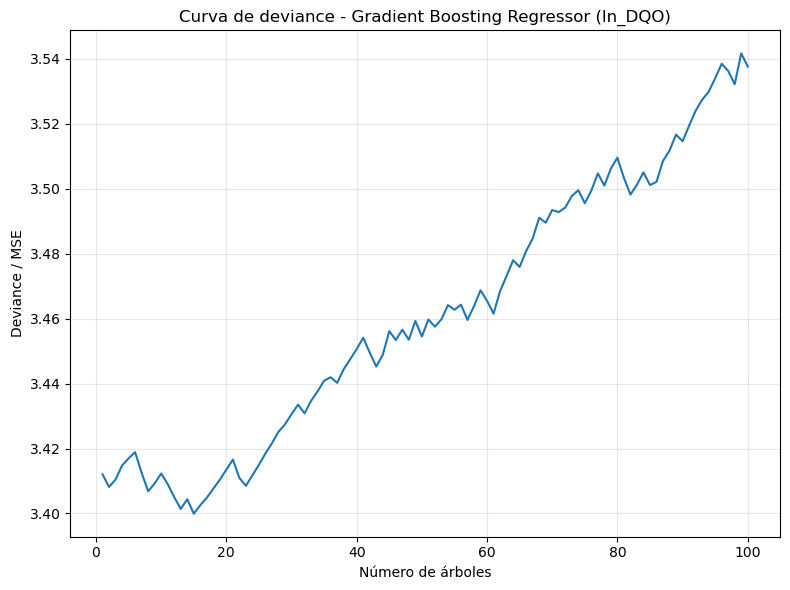

In [7]:
resultados, df_metricas = pipeline_evaluacion_modelos(
    modelos=modelos,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    target=target_modelo,
    ruta_metricas=ruta_metricas,
    carpeta_figuras=carpeta_figuras
)

## Tabla comparativa de métricas

La siguiente tabla resume el desempeño de cada modelo en los conjuntos de entrenamiento y prueba.

Las métricas incluidas son:

- **R²:** proporción de variabilidad explicada por el modelo.
- **RMSE:** raíz del error cuadrático medio.
- **MAE:** error absoluto medio.

Esta tabla permite comparar el desempeño de SVR, GBR y RFR bajo el mismo split de datos.

In [8]:
df_metricas

,modelo,conjunto,R2,RMSE,MAE
0,SVR,train,-0.003810,0.809464,0.218939
1,SVR,test,-0.219858,1.900126,0.908024
2,GBR,train,0.302310,0.674844,0.283264
3,GBR,test,-0.195246,1.880859,1.050239
4,RFR,train,0.506746,0.567424,0.232548
5,RFR,test,-0.187263,1.874568,1.103764


## Interpretación de las métricas

La comparación entre métricas de entrenamiento y prueba permite identificar posibles comportamientos de sobreajuste o bajo ajuste.

De forma general:

- Un R² alto en entrenamiento y bajo en prueba puede sugerir sobreajuste.
- Un RMSE o MAE menor indica menor error promedio.
- La comparación debe hacerse considerando tanto la magnitud del error como la estabilidad entre entrenamiento y prueba.

Si la variable objetivo usada para modelado corresponde a una columna transformada, como `ln_DQO`, las métricas se calculan sobre la escala logarítmica natural. Por tanto, su interpretación directa en unidades originales debe hacerse con precaución.

## Productos gráficos generados

Durante la evaluación se generan y almacenan las siguientes figuras:

- observado vs estimado para SVR,
- observado vs estimado para GBR,
- observado vs estimado para RFR,
- comparación de RMSE entre modelos,
- comparación general de métricas entre modelos,
- curva de deviance para Gradient Boosting Regressor.

Estas figuras se guardan en:

`outputs/figures/calidad_agua/<PARAMETRO>/`

In [9]:
print("Figuras generadas en:")
print(carpeta_figuras)

print("\nTabla de métricas guardada en:")
print(ruta_metricas)

Figuras generadas en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO

Tabla de métricas guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\metricas_modelos.csv


## Curva de deviance del Gradient Boosting Regressor

La curva de deviance permite observar la evolución del error del modelo Gradient Boosting Regressor a medida que se agregan árboles al ensamble.

En este flujo, la deviance se representa mediante el error cuadrático medio calculado de forma secuencial con `staged_predict()`.

Una reducción progresiva de la curva indica que la incorporación de nuevos árboles contribuye a disminuir el error. Si la curva se estabiliza o comienza a deteriorarse, puede indicar que aumentar el número de estimadores no aporta mejoras relevantes o puede conducir a sobreajuste.


## Consideraciones técnicas

- Los tres modelos se evalúan con el mismo split para asegurar una comparación justa.
- SVR fue entrenado dentro de un `Pipeline` con escalamiento estándar.
- Gradient Boosting Regressor y Random Forest Regressor se evaluaron directamente sobre las variables predictoras.
- Si se aplicó logaritmo natural a la variable objetivo, las métricas corresponden a la escala transformada.
- Las figuras observado vs estimado ayudan a identificar sesgos de subestimación o sobreestimación.
- La comparación de métricas debe interpretarse junto con el conocimiento del parámetro evaluado y la distribución de los datos.

## Producto de esta etapa

Al finalizar este notebook se generan los siguientes productos:

1. Tabla de métricas comparativas:

`outputs/tables/calidad_agua/<PARAMETRO>/metricas_modelos.csv`

2. Figuras de evaluación:

`outputs/figures/calidad_agua/<PARAMETRO>/`

Las rutas se organizan con `target_salida`, por ejemplo `DQO`, aunque el modelo haya sido entrenado con una variable objetivo transformada como `ln_DQO`.

## Siguiente etapa del flujo

Una vez evaluados los modelos, el siguiente paso consiste en analizar la importancia relativa de las variables predictoras para los modelos compatibles con este tipo de interpretación.

Esta fase se documenta en:

`05_analisis_importancia_variables.ipynb`